# Lab 03 — Edge Detection Techniques and Their Impact on Classification Performance

**Dataset:** ISIC skin lesions, same 4 classes and same train/val/test split logic as Lab 02.




In [1]:
# ============ CELL 1: SETUP & CONFIG ============
!pip -q install -U kaggle

import os, time, random, shutil, warnings
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from skimage.feature import hog
import torch, torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 250)

# ---- Config (change here only) ----
SEED = 42
IMG_SIZE = 224
EPOCHS = 10                    # same for every CNN and every set (fair comparison)
LR = 1e-3
BATCH_SIZE = 32
FILTER_B = ("gaussian", 5)     # best Lab 02 filter for Set B: ("gaussian",5) or ("mean",5)
SAMPLE_PER_CLASS = 5           # images per class used for Tasks 1-3 statistics
NOISE_SIGMA = 25               # Gaussian noise std (0-255 scale)
SP_AMOUNT = 0.05               # salt-and-pepper: fraction of pixels corrupted
HOG_SIZE = 128                 # image size for HOG features (classical classifiers)
BEST_CANNY_OVERRIDE = None     # e.g. dict(name="Canny-2", low=50, high=150, ksize=3) to force a choice
OUT_DIR = "/content/lab03_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def save_fig(name):
    plt.savefig(os.path.join(OUT_DIR, name), dpi=150, bbox_inches="tight")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 11.6 MB/s eta 0:00:00
Device: cuda


In [4]:
# ============ CELL 2: DOWNLOAD DATASET (skipped if already present) ============
BASE = "/content/skin_cancer_dataset"
if not os.path.exists(BASE):
    try:
        from google.colab import userdata
        os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
    except Exception:
        import getpass
        os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("KGAT_61d41cc9a755239bbf2cdb33b9b7043e")
    !kaggle datasets download -d nodoubttome/skin-cancer9-classesisic
    !mkdir -p /content/skin_cancer_dataset
    !unzip -q skin-cancer9-classesisic.zip -d /content/skin_cancer_dataset
print("Dataset ready:", os.listdir(BASE))

KGAT_61d41cc9a755239bbf2cdb33b9b7043e··········
Dataset URL: https://www.kaggle.com/datasets/nodoubttome/skin-cancer9-classesisic
License(s): other
100% 786M/786M [00:44<00:00, 18.5MB/s]

Dataset ready: ['Skin cancer ISIC The International Skin Imaging Collaboration']


In [5]:
# ============ CELL 3: SPLITS + LOAD IMAGES (same logic as Lab 02) ============
dataset_path = os.path.join(BASE, "Skin cancer ISIC The International Skin Imaging Collaboration")
train_path, test_path = os.path.join(dataset_path, "Train"), os.path.join(dataset_path, "Test")
selected_classes = ["melanoma", "basal cell carcinoma", "nevus", "pigmented benign keratosis"]
class_names = sorted(selected_classes)
class_to_index = {c: i for i, c in enumerate(class_names)}
short_names = {"basal cell carcinoma": "BCC", "melanoma": "Melanoma", "nevus": "Nevus",
               "pigmented benign keratosis": "PBK"}

def collect(split_path):
    rows = []
    for c in selected_classes:
        folder = os.path.join(split_path, c)
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                rows.append({"filepath": os.path.join(folder, f), "class": c})
    return pd.DataFrame(rows)

train_all, test_df = collect(train_path), collect(test_path)
train_df, val_df = train_test_split(train_all, test_size=0.20, stratify=train_all["class"], random_state=SEED)
train_df, val_df, test_df = [d.reset_index(drop=True) for d in (train_df, val_df, test_df)]
for d in (train_df, val_df, test_df):
    d["label"] = d["class"].map(class_to_index)
print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

def load_rgb(path):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

t0 = time.time()
X_train_raw = np.stack([load_rgb(p) for p in train_df.filepath])
X_val_raw   = np.stack([load_rgb(p) for p in val_df.filepath])
X_test_raw  = np.stack([load_rgb(p) for p in test_df.filepath])
y_train, y_val, y_test = [d["label"].values.astype(np.int64) for d in (train_df, val_df, test_df)]
print(f"Loaded images in {time.time()-t0:.0f}s:", X_train_raw.shape, X_val_raw.shape, X_test_raw.shape)

to_gray = lambda rgb: cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
G_train = np.stack([to_gray(x) for x in X_train_raw])
G_val   = np.stack([to_gray(x) for x in X_val_raw])
G_test  = np.stack([to_gray(x) for x in X_test_raw])

# Images used for Tasks 1-3 (from the TEST split, 5 per class) and one representative per class
sample_idx = test_df.groupby("class", sort=False).head(SAMPLE_PER_CLASS).index.to_numpy()
rep_idx = [test_df.index[test_df["class"] == c][0] for c in class_names]
print("Sample images for Tasks 1-3:", len(sample_idx))

Train/Val/Test: 1306 327 64
Loaded images in 24s: (1306, 224, 224, 3) (327, 224, 224, 3) (64, 224, 224, 3)
Sample images for Tasks 1-3: 20


In [6]:
# ============ CELL 4: EDGE DETECTORS, NOISE, FILTERS, METRICS ============
def sobel_gx(g): return cv2.Sobel(g, cv2.CV_64F, 1, 0, ksize=3)
def sobel_gy(g): return cv2.Sobel(g, cv2.CV_64F, 0, 1, ksize=3)
def sobel_mag(g): return cv2.magnitude(sobel_gx(g), sobel_gy(g))

PREWITT_X = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float64)
PREWITT_Y = PREWITT_X.T
def prewitt_mag(g):
    gf = g.astype(np.float64)
    return cv2.magnitude(cv2.filter2D(gf, -1, PREWITT_X), cv2.filter2D(gf, -1, PREWITT_Y))

def laplacian(g):
    return np.abs(cv2.Laplacian(g.astype(np.float64), cv2.CV_64F, ksize=3))

def log_edge(g, sigma=1.5):
    k = int(2 * np.ceil(3 * sigma) + 1)
    blurred = cv2.GaussianBlur(g.astype(np.float64), (k, k), sigma)
    return np.abs(cv2.Laplacian(blurred, cv2.CV_64F, ksize=3))   # |LoG| response

def canny(g, low=50, high=150, ksize=5):
    # Stage 1 of Canny = Gaussian smoothing (OpenCV's Canny does not do it internally), then gradient, NMS, hysteresis
    return cv2.Canny(cv2.GaussianBlur(g, (ksize, ksize), 0), low, high).astype(np.float64)

DETECTORS = {"Sobel": sobel_mag, "Prewitt": prewitt_mag, "Laplacian": laplacian, "LoG": log_edge, "Canny": canny}

def disp(det, m):
    """Scale an edge response to 0-1 for display."""
    if det == "Canny": return m / 255.0
    m = np.abs(m); hi = np.percentile(m, 99.5)
    return np.clip(m / hi, 0, 1) if hi > 0 else m

# ---- Noise ----
def add_gaussian_noise(g, rng, sigma=NOISE_SIGMA):
    return np.clip(g.astype(np.float64) + rng.normal(0, sigma, g.shape), 0, 255).astype(np.uint8)

def add_salt_pepper(g, rng, amount=SP_AMOUNT):
    out, r = g.copy(), rng.random(g.shape)
    out[r < amount / 2] = 0
    out[r > 1 - amount / 2] = 255
    return out

def build_input(g, noise, pre, rng):
    x = g
    if noise == "Gaussian": x = add_gaussian_noise(g, rng)
    elif noise == "Salt & Pepper": x = add_salt_pepper(g, rng)
    if pre == "Gaussian Filter": x = cv2.GaussianBlur(x, (5, 5), 0)
    elif pre == "Median Filter": x = cv2.medianBlur(x, 5)
    return x                                     # "None" / "Built-in smoothing" -> no external filter

# ---- Edge-map metrics (compare against the same detector on the CLEAN image) ----
K3 = np.ones((3, 3), np.uint8)
def ref_params(clean_map, det):
    if det == "Canny": return 1.0, 0
    scale = 255.0 / max(clean_map.max(), 1e-9)
    t, _ = cv2.threshold((clean_map * scale).astype(np.uint8), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return scale, t

def binarize(m, scale, t): return (m * scale) > t     # threshold fixed from the clean image

def edge_metrics(E, R):
    E8, R8 = E.astype(np.uint8), R.astype(np.uint8)
    Ed, Rd = cv2.dilate(E8, K3), cv2.dilate(R8, K3)          # 1-pixel localisation tolerance
    ne, nr = int(E8.sum()), int(R8.sum())
    prec = (E8 & Rd).sum() / ne if ne else 0.0
    rec = (R8 & Ed).sum() / nr if nr else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    comps = cv2.connectedComponents(E8, connectivity=8)[0] - 1
    rcomps = cv2.connectedComponents(R8, connectivity=8)[0] - 1
    return dict(F1=f1, FalseEdge=(1 - prec) if ne else 0.0, Recall=rec,
                Density=E8.mean() * 100, Segments=comps, FragRatio=comps / max(rcomps, 1))

def evaluate_condition(det, noise, pre, seed=SEED):
    fn, rng, rows = DETECTORS[det], np.random.default_rng(seed), []
    for i in sample_idx:
        g = G_test[i]
        clean = fn(g)
        scale, t = ref_params(clean, det)
        R = binarize(clean, scale, t)
        E = binarize(fn(build_input(g, noise, pre, rng)), scale, t)
        rows.append(edge_metrics(E, R))
    return pd.DataFrame(rows).mean()
print("Edge detectors ready:", list(DETECTORS))

Edge detectors ready: ['Sobel', 'Prewitt', 'Laplacian', 'LoG', 'Canny']


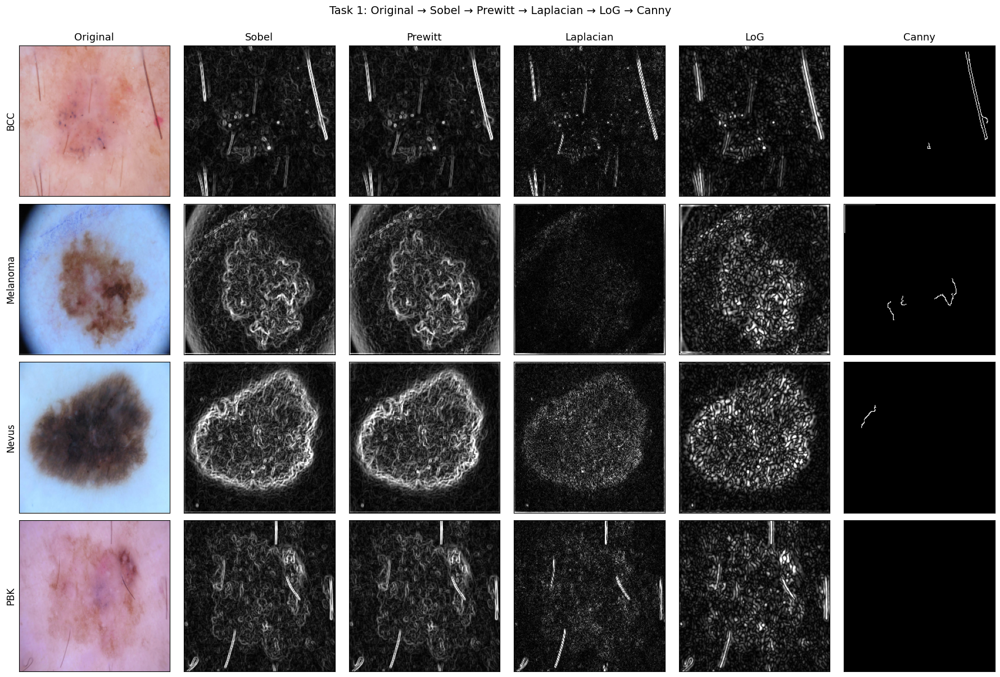

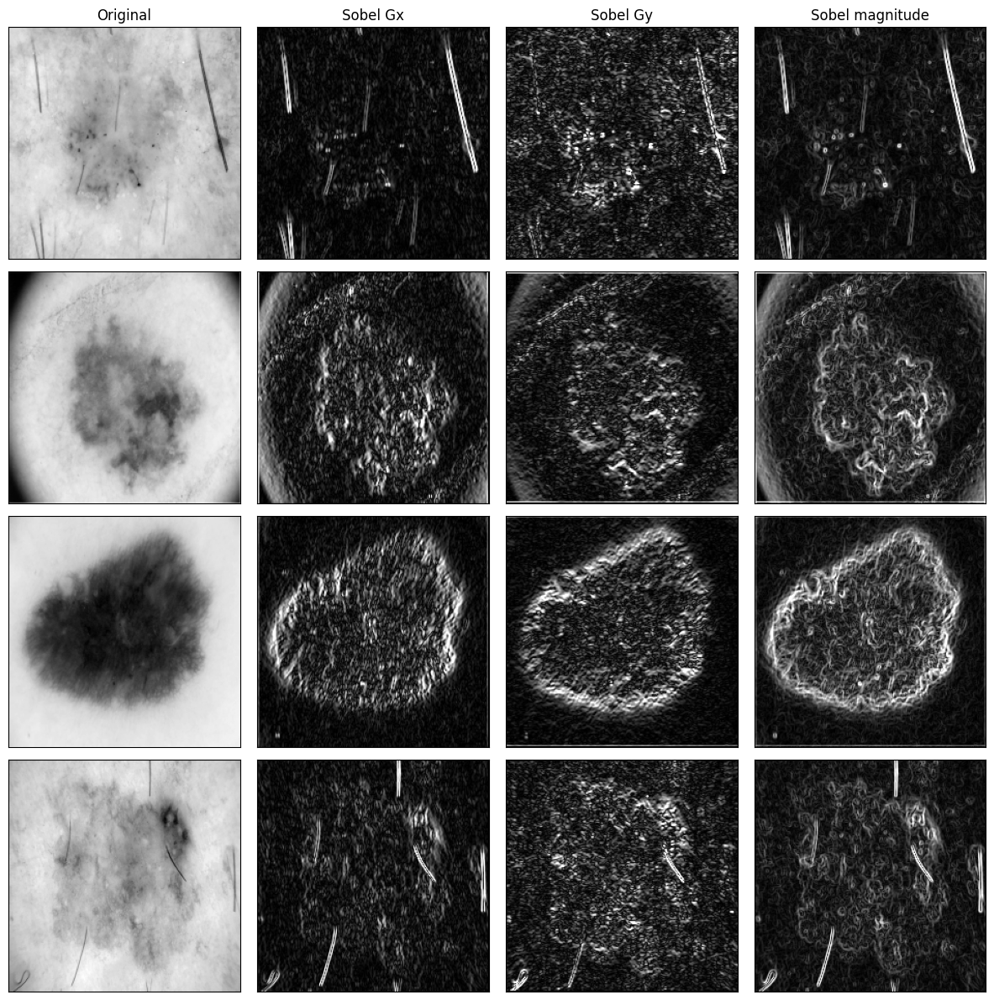

In [7]:
# ============ CELL 5: TASK 1 — COMPARATIVE EDGE DETECTION ============
cols = ["Original", "Sobel", "Prewitt", "Laplacian", "LoG", "Canny"]
fig, axes = plt.subplots(len(rep_idx), len(cols), figsize=(3 * len(cols), 3 * len(rep_idx)))
for r, i in enumerate(rep_idx):
    g = G_test[i]
    axes[r, 0].imshow(X_test_raw[i]); axes[r, 0].set_ylabel(short_names[class_names[r]], fontsize=12)
    for c, det in enumerate(cols[1:], start=1):
        axes[r, c].imshow(disp(det, DETECTORS[det](g)), cmap="gray")
    for c in range(len(cols)):
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0: axes[r, c].set_title(cols[c], fontsize=13)
plt.suptitle("Task 1: Original → Sobel → Prewitt → Laplacian → LoG → Canny", y=1.0, fontsize=14)
plt.tight_layout(); save_fig("task1_edge_comparison.png"); plt.show()

# First-order detail: Sobel Gx, Gy, magnitude
fig, axes = plt.subplots(len(rep_idx), 4, figsize=(12, 3 * len(rep_idx)))
for r, i in enumerate(rep_idx):
    g = G_test[i]
    for c, (title, m) in enumerate([("Original", None), ("Sobel Gx", sobel_gx(g)), ("Sobel Gy", sobel_gy(g)), ("Sobel magnitude", sobel_mag(g))]):
        axes[r, c].imshow(g, cmap="gray") if m is None else axes[r, c].imshow(disp("Sobel", m), cmap="gray")
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([])
        if r == 0: axes[r, c].set_title(title)
plt.tight_layout(); save_fig("task1_sobel_gx_gy_mag.png"); plt.show()

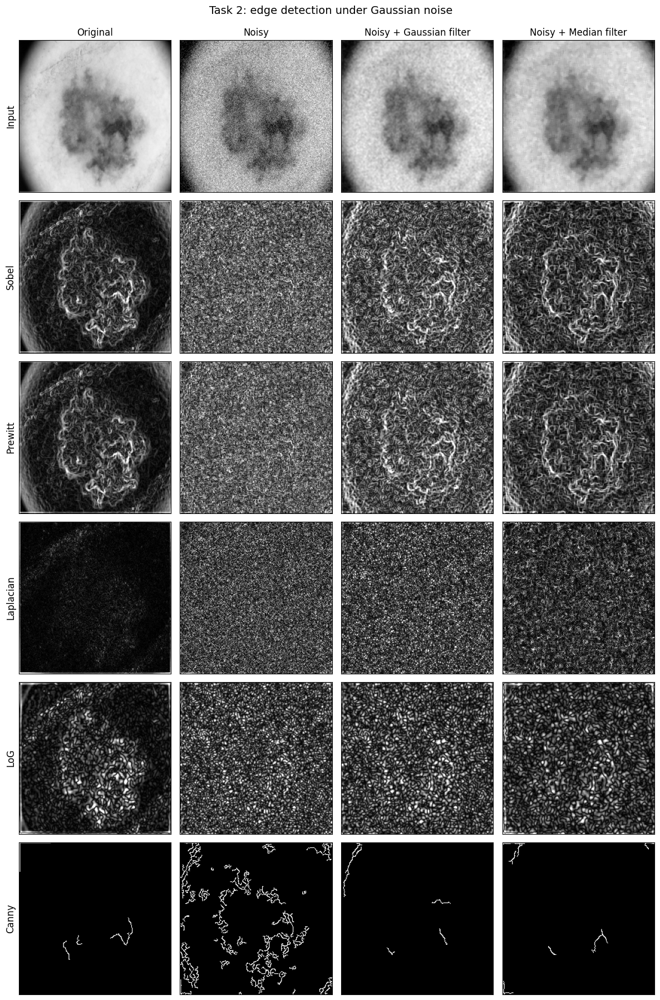

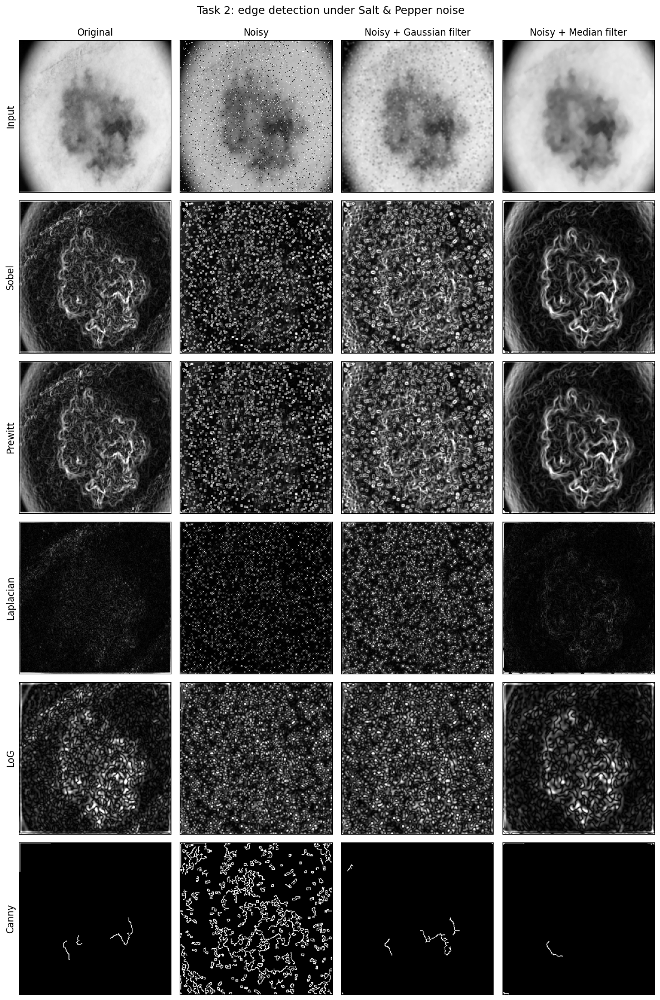

TABLE 1. Effect of Noise and Preprocessing on Edge Detection (mean over 20 images)


,Edge Detector,Input Image,Noise Type,Preprocessing,Edge Quality,Noise Sensitivity,Observations,F1 vs clean edges,False edges (%),Edge density (%),Segments
0,Sobel,Original,None,None,Reference (clean),—,"Clean-image reference: 13.6% edge pixels, 307 segments",—,—,13.62,306.9
1,Sobel,Noisy,Gaussian,None,Fair,High,many false edges; edges much more fragmented/broken than clean,0.451,68.3,79.06,157.2
2,Sobel,Noisy,Salt & Pepper,None,Fair,High,many false edges; edges much more fragmented/broken than clean,0.562,57.3,40.16,437.8
3,Sobel,Noisy,Gaussian,Gaussian Filter,Good,Medium,some false edges; edges much more fragmented/broken than clean,0.633,46.8,36.41,413.7
4,Sobel,Noisy,Salt & Pepper,Median Filter,Good,Low,few false edges; edges less fragmented than clean (smoothing merged/removed detail); weak/fine edges lost (recall 0.60),0.715,0.0,6.66,82.0
5,Prewitt,Original,None,None,Reference (clean),—,"Clean-image reference: 13.6% edge pixels, 311 segments",—,—,13.63,311.2
6,Laplacian,Original,None,None,Reference (clean),—,"Clean-image reference: 8.7% edge pixels, 542 segments",—,—,8.68,541.7
7,LoG,Noisy,Gaussian,Gaussian Filter,Fair,High,many false edges; edges much more fragmented/broken than clean,0.571,56.7,40.59,765.5
8,Canny,Original,None,Built-in smoothing,Reference (clean),—,"Clean-image reference: 0.7% edge pixels, 6 segments",—,—,0.71,5.9
9,Canny,Noisy,Gaussian,Gaussian Filter,Poor,Medium,some false edges; edges less fragmented than clean (smoothing merged/removed detail); weak/fine edges lost (recall 0.30),0.301,29.8,0.51,6.0



SUPPLEMENTARY TABLE 1b. F1 vs clean edges (higher = more robust to noise)


Noise                Gaussian                        Salt & Pepper                     
Preprocessing Gaussian Filter Median Filter   None Gaussian Filter Median Filter   None
Detector                                                                               
Canny                   0.301         0.273  0.165           0.267         0.230  0.096
Laplacian               0.367         0.501  0.353           0.336         0.524  0.479
LoG                     0.571         0.588  0.516           0.548         0.774  0.527
Prewitt                 0.636         0.626  0.450           0.553         0.722  0.561
Sobel                   0.633         0.621  0.451           0.552         0.715  0.562

In [8]:
# ============ CELL 6: TASK 2 — NOISE + TABLE 1 ============
# (a) Visual: rows = input + 5 detectors, columns = Original / Noisy / Noisy+Gaussian filter / Noisy+Median filter
demo = G_test[rep_idx[1]]
for noise in ["Gaussian", "Salt & Pepper"]:
    variants = [("Original", "None", "None"), ("Noisy", noise, "None"),
                ("Noisy + Gaussian filter", noise, "Gaussian Filter"), ("Noisy + Median filter", noise, "Median Filter")]
    inputs = []
    for title, nz, pre in variants:
        inputs.append(build_input(demo, nz, pre, np.random.default_rng(SEED)))   # same noise realisation in each column
    fig, axes = plt.subplots(6, 4, figsize=(12, 18))
    for c, (x, (title, _, _)) in enumerate(zip(inputs, variants)):
        axes[0, c].imshow(x, cmap="gray"); axes[0, c].set_title(title)
        for r, det in enumerate(DETECTORS, start=1):
            axes[r, c].imshow(disp(det, DETECTORS[det](x)), cmap="gray")
            if c == 0: axes[r, c].set_ylabel(det, fontsize=12)
    axes[0, 0].set_ylabel("Input", fontsize=12)
    for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
    plt.suptitle(f"Task 2: edge detection under {noise} noise", y=0.995, fontsize=14)
    plt.tight_layout(); save_fig(f"task2_noise_{noise.replace(' & ', '_').replace(' ', '_').lower()}.png"); plt.show()

# (b) Table 1 — rows exactly as in the lab sheet
TABLE1_ROWS = [
    ("Sobel", "Original", "None", "None"),
    ("Sobel", "Noisy", "Gaussian", "None"),
    ("Sobel", "Noisy", "Salt & Pepper", "None"),
    ("Sobel", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Sobel", "Noisy", "Salt & Pepper", "Median Filter"),
    ("Prewitt", "Original", "None", "None"),
    ("Laplacian", "Original", "None", "None"),
    ("LoG", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Canny", "Original", "None", "Built-in smoothing"),
    ("Canny", "Noisy", "Gaussian", "Gaussian Filter"),
    ("Canny", "Noisy", "Salt & Pepper", "Median Filter"),
]
# Heuristic labels (edit the words if your visual inspection disagrees):
#   Edge Quality: F1 vs clean edges >=0.60 Good, >=0.35 Fair, else Poor
#   Noise Sensitivity: share of false edge pixels <0.25 Low, <0.50 Medium, else High
def quality_label(f1): return "Good" if f1 >= 0.60 else "Fair" if f1 >= 0.35 else "Poor"
def sens_label(fe): return "Low" if fe < 0.25 else "Medium" if fe < 0.50 else "High"

def observation(m, det):
    fe = "many false edges" if m.FalseEdge >= 0.5 else "some false edges" if m.FalseEdge >= 0.25 else "few false edges"
    fr = ("edges much more fragmented/broken than clean" if m.FragRatio > 2 else
          "edges somewhat more fragmented" if m.FragRatio > 1.25 else
          "edges less fragmented than clean (smoothing merged/removed detail)" if m.FragRatio < 0.8 else "continuity similar to clean")
    lost = "; weak/fine edges lost (recall %.2f)" % m.Recall if m.Recall < 0.6 else ""
    return f"{fe}; {fr}{lost}"

rows = []
for det, inp, noise, pre in TABLE1_ROWS:
    m = evaluate_condition(det, "None" if inp == "Original" else noise, "None" if pre in ("None", "Built-in smoothing") else pre)
    if inp == "Original":
        rows.append([det, inp, noise, pre, "Reference (clean)", "—",
                     f"Clean-image reference: {m.Density:.1f}% edge pixels, {m.Segments:.0f} segments", "—", "—", round(m.Density, 2), round(m.Segments, 1)])
    else:
        rows.append([det, inp, noise, pre, quality_label(m.F1), sens_label(m.FalseEdge), observation(m, det),
                     round(m.F1, 3), round(m.FalseEdge * 100, 1), round(m.Density, 2), round(m.Segments, 1)])
table1 = pd.DataFrame(rows, columns=["Edge Detector", "Input Image", "Noise Type", "Preprocessing", "Edge Quality",
                                     "Noise Sensitivity", "Observations", "F1 vs clean edges", "False edges (%)", "Edge density (%)", "Segments"])
print("TABLE 1. Effect of Noise and Preprocessing on Edge Detection (mean over %d images)" % len(sample_idx))
display(table1)
table1.to_csv(os.path.join(OUT_DIR, "table1_noise_preprocessing.csv"), index=False)

# (c) Full grid for Q1/Q2: every detector x noise x preprocessing
grid = []
for det in DETECTORS:
    for noise in ["Gaussian", "Salt & Pepper"]:
        for pre in ["None", "Gaussian Filter", "Median Filter"]:
            m = evaluate_condition(det, noise, pre)
            grid.append(dict(Detector=det, Noise=noise, Preprocessing=pre, F1=m.F1, FalseEdge=m.FalseEdge * 100, Density=m.Density))
grid = pd.DataFrame(grid)
print("\nSUPPLEMENTARY TABLE 1b. F1 vs clean edges (higher = more robust to noise)")
display(grid.pivot_table(index="Detector", columns=["Noise", "Preprocessing"], values="F1").round(3))
grid.to_csv(os.path.join(OUT_DIR, "table1b_full_grid.csv"), index=False)

TABLE 2. Canny Parameter Analysis (Number of Detected Edges = mean edge pixels per 224×224 image, train set)


,Configuration,Low Threshold,High Threshold,Kernel Size,Edge Quality,Number of Detected Edges,Observation,Edge density (%),Segments/image,Val accuracy (%)
0,Canny-1,30,100,3×3,Balanced,1925,"3.8% edge pixels, ~34 segments/image; val acc 43.7% (HOG+SVM)",3.84,33.8,43.73
1,Canny-2,50,150,3×3,Sparse / under-detected,729,"1.5% edge pixels, ~11 segments/image; val acc 40.7% (HOG+SVM)",1.45,10.8,40.67
2,Canny-3,100,200,3×3,Sparse / under-detected,271,"0.5% edge pixels, ~4 segments/image; val acc 36.1% (HOG+SVM)",0.54,4.2,36.09
3,Canny-4,50,150,5×5,Sparse / under-detected,412,"0.8% edge pixels, ~6 segments/image; val acc 40.1% (HOG+SVM)",0.82,5.9,40.06



Selected for Task 4: Canny-1  (low=30, high=100, Gaussian 3x3)


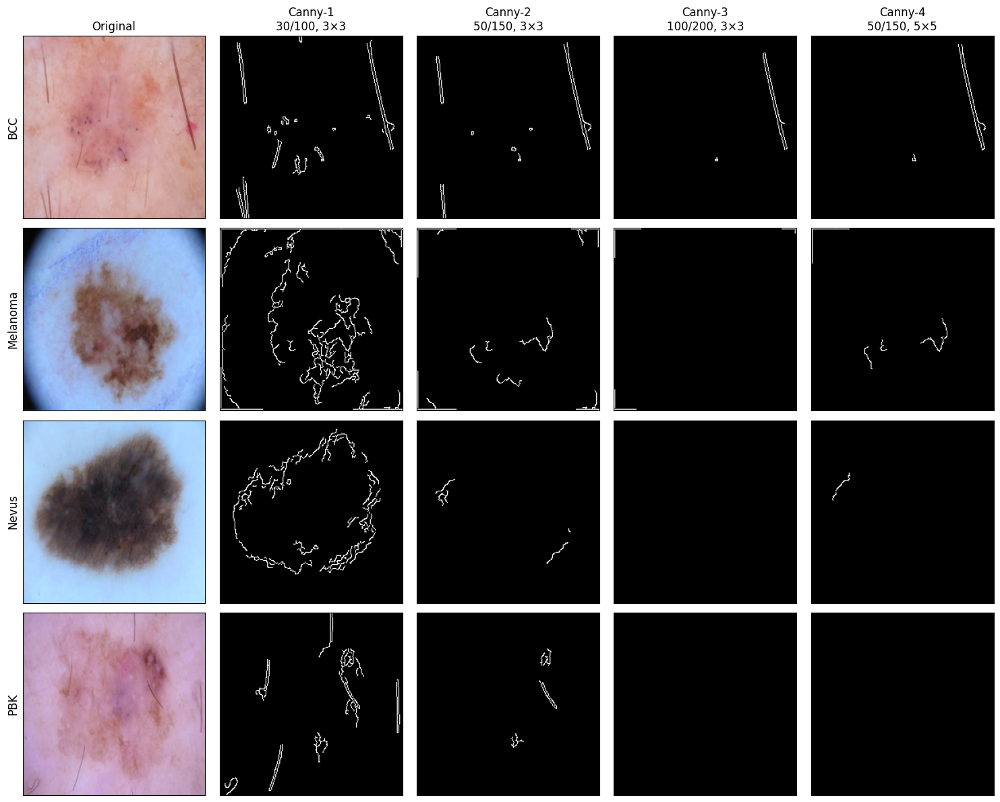

In [9]:
# ============ CELL 7: TASK 3 — CANNY PARAMETERS + TABLE 2 ============
CANNY_CONFIGS = [("Canny-1", 30, 100, 3), ("Canny-2", 50, 150, 3), ("Canny-3", 100, 200, 3),
                 ("Canny-4", 50, 150, 5)]        # Canny-4: 5x5 Gaussian kernel (thresholds not specified in the sheet, so 50/150)

def canny_maps(G, low, high, k):
    return np.stack([canny(g, low, high, k).astype(np.uint8) for g in G])

def hog_feats(G):
    out = []
    for g in G:
        s = cv2.resize(g, (HOG_SIZE, HOG_SIZE), interpolation=cv2.INTER_AREA)
        out.append(hog(s, orientations=9, pixels_per_cell=(16, 16), cells_per_block=(2, 2), block_norm="L2-Hys"))
    return np.array(out, dtype=np.float32)

rows, cfg_val_acc = [], {}
for name, lo, hi, k in CANNY_CONFIGS:
    Etr, Eva = canny_maps(G_train, lo, hi, k), canny_maps(G_val, lo, hi, k)
    clf = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale"))
    clf.fit(hog_feats(Etr), y_train)
    va = clf.score(hog_feats(Eva), y_val)                      # selection uses VALIDATION accuracy only (no test leakage)
    px = (Etr > 0).reshape(len(Etr), -1).sum(1).mean()
    dens = px / (IMG_SIZE * IMG_SIZE) * 100
    segs = np.mean([cv2.connectedComponents((canny(G_test[i], lo, hi, k) > 0).astype(np.uint8), connectivity=8)[0] - 1 for i in sample_idx])
    quality = "Sparse / under-detected" if dens < 2 else "Cluttered / over-detected" if dens > 15 else "Balanced"
    cfg_val_acc[name] = va
    rows.append([name, lo, hi, f"{k}×{k}", quality, int(round(px)), f"{dens:.1f}% edge pixels, ~{segs:.0f} segments/image; val acc {va*100:.1f}% (HOG+SVM)",
                 round(dens, 2), round(segs, 1), round(va * 100, 2)])
table2 = pd.DataFrame(rows, columns=["Configuration", "Low Threshold", "High Threshold", "Kernel Size", "Edge Quality",
                                     "Number of Detected Edges", "Observation", "Edge density (%)", "Segments/image", "Val accuracy (%)"])
print("TABLE 2. Canny Parameter Analysis (Number of Detected Edges = mean edge pixels per 224×224 image, train set)")
display(table2)
table2.to_csv(os.path.join(OUT_DIR, "table2_canny_parameters.csv"), index=False)

# Select best config by validation accuracy
best_row = table2.loc[table2["Val accuracy (%)"].idxmax()]
BEST = dict(name=best_row["Configuration"], low=int(best_row["Low Threshold"]), high=int(best_row["High Threshold"]),
            ksize=int(str(best_row["Kernel Size"])[0]))
if BEST_CANNY_OVERRIDE: BEST = BEST_CANNY_OVERRIDE
print(f"\nSelected for Task 4: {BEST['name']}  (low={BEST['low']}, high={BEST['high']}, Gaussian {BEST['ksize']}x{BEST['ksize']})")

# Visual comparison of the configs
fig, axes = plt.subplots(len(rep_idx), len(CANNY_CONFIGS) + 1, figsize=(3 * (len(CANNY_CONFIGS) + 1), 3 * len(rep_idx)))
for r, i in enumerate(rep_idx):
    axes[r, 0].imshow(X_test_raw[i]); axes[r, 0].set_ylabel(short_names[class_names[r]], fontsize=12)
    if r == 0: axes[r, 0].set_title("Original")
    for c, (name, lo, hi, k) in enumerate(CANNY_CONFIGS, start=1):
        axes[r, c].imshow(canny(G_test[i], lo, hi, k) / 255.0, cmap="gray")
        if r == 0: axes[r, c].set_title(f"{name}\n{lo}/{hi}, {k}×{k}")
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); save_fig("task3_canny_configs.png"); plt.show()

In [10]:
# ============ CELL 8: TASK 4 — BUILD SETS A / B / C ============
def apply_filter_B(rgb):
    name, k = FILTER_B
    return cv2.GaussianBlur(rgb, (k, k), 0) if name == "gaussian" else cv2.blur(rgb, (k, k))

def apply_edge(rgb):
    return canny(to_gray(rgb), BEST["low"], BEST["high"], BEST["ksize"]).astype(np.uint8)

def make_set(X_rgb, kind):
    if kind == "Raw":      return X_rgb
    if kind == "Filtered": return np.stack([apply_filter_B(x) for x in X_rgb])
    e = np.stack([apply_edge(x) for x in X_rgb])                     # Edge: single channel -> replicate to 3 channels for the CNNs
    return np.repeat(e[..., None], 3, axis=-1)

SET_NAMES = ["Raw", "Filtered", "Edge"]
SETS = {s: {"train": make_set(X_train_raw, s), "val": make_set(X_val_raw, s), "test": make_set(X_test_raw, s)} for s in SET_NAMES}
Y = {"train": y_train, "val": y_val, "test": y_test}
print("Sets built:", {s: SETS[s]["train"].shape for s in SETS})
print(f"Set A = raw | Set B = {FILTER_B[0]} {FILTER_B[1]}x{FILTER_B[1]} | Set C = Canny {BEST['low']}/{BEST['high']} ({BEST['ksize']}x{BEST['ksize']})")

# Preprocessing cost per image (ms) — included in the reported inference time so the comparison is end-to-end
def time_prep(fn, X):
    t = time.perf_counter()
    for x in X: fn(x)
    return (time.perf_counter() - t) / len(X) * 1000
PREP_MS = {"Raw": 0.0, "Filtered": time_prep(apply_filter_B, X_test_raw), "Edge": time_prep(apply_edge, X_test_raw)}
print("Preprocessing ms/image:", {k: round(v, 3) for k, v in PREP_MS.items()})

# One row per (model, set)
RESULTS, PRED = [], {}
def log_result(model, sname, y_true, y_pred, val_acc, train_s, infer_ms):
    PRED[(model, sname)] = y_pred
    RESULTS.append({"Model": model, "Set": sname, "Val Acc": val_acc,
                    "Accuracy": accuracy_score(y_true, y_pred),
                    "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
                    "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
                    "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
                    "Macro-F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
                    "Train time (s)": train_s, "Inference (ms/img)": infer_ms})

Sets built: {'Raw': (1306, 224, 224, 3), 'Filtered': (1306, 224, 224, 3), 'Edge': (1306, 224, 224, 3)}
Set A = raw | Set B = gaussian 5x5 | Set C = Canny 30/100 (3x3)
Preprocessing ms/image: {'Raw': 0.0, 'Filtered': 0.145, 'Edge': 0.397}


In [11]:
# ============ CELL 9: TASK 5a — CLASSICAL CLASSIFIERS (HOG features) ============
def gray_of(sname, X):
    return X[..., 0] if sname == "Edge" else np.stack([to_gray(x) for x in X])

FEATS, HOG_MS = {}, {}
for s in SET_NAMES:
    FEATS[s] = {}
    for split in ("train", "val"):
        FEATS[s][split] = hog_feats(gray_of(s, SETS[s][split]))
    g_te = gray_of(s, SETS[s]["test"])
    t = time.perf_counter(); FEATS[s]["test"] = hog_feats(g_te); HOG_MS[s] = (time.perf_counter() - t) / len(g_te) * 1000
print("HOG feature length:", FEATS["Raw"]["train"].shape[1])

CLASSICAL = {
    "SVM": lambda: make_pipeline(StandardScaler(), SVC(kernel="rbf", C=10, gamma="scale")),
    "Random Forest": lambda: RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
    "KNN": lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
}
for mname, make in CLASSICAL.items():
    for s in SET_NAMES:
        clf = make()
        t = time.perf_counter(); clf.fit(FEATS[s]["train"], y_train); train_s = time.perf_counter() - t
        val_acc = clf.score(FEATS[s]["val"], y_val)
        t = time.perf_counter(); pred = clf.predict(FEATS[s]["test"]); pred_ms = (time.perf_counter() - t) / len(y_test) * 1000
        infer_ms = pred_ms + HOG_MS[s] + PREP_MS[s]          # end-to-end: preprocessing + HOG + classifier
        log_result(mname, s, y_test, pred, val_acc, train_s, infer_ms)
        print(f"{mname:14s} | {s:8s} | val {val_acc*100:5.1f}% | test {RESULTS[-1]['Accuracy']*100:5.1f}%")

HOG feature length: 1764
SVM            | Raw      | val  48.6% | test  43.8%
SVM            | Filtered | val  45.6% | test  45.3%
SVM            | Edge     | val  43.7% | test  42.2%
Random Forest  | Raw      | val  47.1% | test  43.8%
Random Forest  | Filtered | val  45.6% | test  46.9%
Random Forest  | Edge     | val  45.3% | test  37.5%
KNN            | Raw      | val  39.4% | test  40.6%
KNN            | Filtered | val  36.1% | test  37.5%
KNN            | Edge     | val  41.0% | test  34.4%


In [12]:
# ============ CELL 10: TASK 5b — CNN MODELS (PyTorch) ============
MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
def to_tensor(xb):                                           # uint8 NHWC -> normalised float NCHW on device
    t = torch.from_numpy(xb).to(device).permute(0, 3, 1, 2).float() / 255.0
    return (t - MEAN) / STD

class ResNet18TL(nn.Module):
    """CNN Model 1: ImageNet ResNet18, frozen backbone, new 4-class head (Lab 02 setup)."""
    def __init__(self, n=4):
        super().__init__()
        m = resnet18(weights=ResNet18_Weights.DEFAULT)
        m.fc = nn.Identity()
        for p in m.parameters(): p.requires_grad = False
        self.backbone, self.head = m, nn.Linear(512, n)
    def train(self, mode=True):
        super().train(mode); self.backbone.eval(); return self   # keep frozen BatchNorm statistics fixed
    def forward(self, x):
        with torch.no_grad(): f = self.backbone(x)
        return self.head(f)

class SmallCNN(nn.Module):
    """CNN Model 2: small CNN trained from scratch (4 conv blocks)."""
    def __init__(self, n=4):
        super().__init__()
        blk = lambda i, o: nn.Sequential(nn.Conv2d(i, o, 3, padding=1), nn.BatchNorm2d(o), nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(blk(3, 16), blk(16, 32), blk(32, 64), blk(64, 128))
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, n))
    def forward(self, x): return self.head(self.features(x))

@torch.no_grad()
def predict(model, X, bs=64):
    model.eval()
    return np.concatenate([model(to_tensor(X[i:i + bs])).argmax(1).cpu().numpy() for i in range(0, len(X), bs)])

def train_cnn(make_model, Xtr, ytr, Xva, yva):
    torch.manual_seed(SEED); rng = np.random.RandomState(SEED)
    model = make_model().to(device)
    opt = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=LR)
    crit, best_val, best_state = nn.CrossEntropyLoss(), -1.0, None
    t0 = time.perf_counter()
    for ep in range(EPOCHS):
        model.train()
        perm = rng.permutation(len(Xtr))
        for i in range(0, len(perm), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            loss = crit(model(to_tensor(Xtr[idx])), torch.from_numpy(ytr[idx]).to(device))
            opt.zero_grad(); loss.backward(); opt.step()
        va = float((predict(model, Xva) == yva).mean())
        if va > best_val: best_val, best_state = va, {k: v.detach().clone() for k, v in model.state_dict().items()}
    if device.type == "cuda": torch.cuda.synchronize()
    train_s = time.perf_counter() - t0
    model.load_state_dict(best_state)                        # best-validation epoch
    return model, train_s, best_val

def timed_predict(model, X):
    predict(model, X[:BATCH_SIZE])                           # warm-up
    if device.type == "cuda": torch.cuda.synchronize()
    t = time.perf_counter(); pred = predict(model, X)
    if device.type == "cuda": torch.cuda.synchronize()
    return pred, (time.perf_counter() - t) / len(X) * 1000

CNNS = {"CNN Model 1 (ResNet18)": ResNet18TL, "CNN Model 2 (Small CNN)": SmallCNN}
for mname, make in CNNS.items():
    for s in SET_NAMES:
        model, train_s, val_acc = train_cnn(make, SETS[s]["train"], y_train, SETS[s]["val"], y_val)
        pred, pred_ms = timed_predict(model, SETS[s]["test"])
        log_result(mname, s, y_test, pred, val_acc, train_s, pred_ms + PREP_MS[s])
        print(f"{mname:24s} | {s:8s} | val {val_acc*100:5.1f}% | test {RESULTS[-1]['Accuracy']*100:5.1f}% | {train_s:.0f}s")
        del model
        if device.type == "cuda": torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


CNN Model 1 (ResNet18)   | Raw      | val  69.7% | test  64.1% | 21s
CNN Model 1 (ResNet18)   | Filtered | val  70.6% | test  60.9% | 20s
CNN Model 1 (ResNet18)   | Edge     | val  45.3% | test  42.2% | 20s
CNN Model 2 (Small CNN)  | Raw      | val  66.1% | test  50.0% | 17s
CNN Model 2 (Small CNN)  | Filtered | val  65.7% | test  57.8% | 18s
CNN Model 2 (Small CNN)  | Edge     | val  37.0% | test  46.9% | 18s


In [13]:
# ============ CELL 11: TASK 5c — TABLE 3 ============
results_df = pd.DataFrame(RESULTS)
results_df.to_csv(os.path.join(OUT_DIR, "results_full_all_sets.csv"), index=False)

model_order = ["SVM", "Random Forest", "KNN", "CNN Model 1 (ResNet18)", "CNN Model 2 (Small CNN)"]
acc = results_df.pivot(index="Model", columns="Set", values="Accuracy").reindex(model_order) * 100
edge = results_df[results_df["Set"] == "Edge"].set_index("Model").reindex(model_order)
table3 = pd.DataFrame({
    "Model / Classifier": model_order,
    "Accuracy Raw (Lab 1)": acc["Raw"].round(2).values,
    "Accuracy Filtered (Lab 2)": acc["Filtered"].round(2).values,
    "Accuracy Edge (Lab 3)": acc["Edge"].round(2).values,
    "Precision": (edge["Precision"] * 100).round(2).values,
    "Recall": (edge["Recall"] * 100).round(2).values,
    "F1-Score": (edge["F1"] * 100).round(2).values,
    "Training Time (s)": edge["Train time (s)"].round(2).values,
    "Inference Time (ms)": edge["Inference (ms/img)"].round(3).values,
})
print("TABLE 3. Cross-Lab Classification Performance Comparison (test set, %d images)" % len(y_test))
print("Accuracy columns = each representation re-run in this notebook with the same split/epochs.")
print("Precision/Recall/F1/Training/Inference columns = Edge set (Set C); all sets are in results_full_all_sets.csv.\n")
display(table3)
table3.to_csv(os.path.join(OUT_DIR, "table3_cross_lab.csv"), index=False)

print("\nFull results (all models x all sets):")
display(results_df.round(4))

TABLE 3. Cross-Lab Classification Performance Comparison (test set, 64 images)
Accuracy columns = each representation re-run in this notebook with the same split/epochs.
Precision/Recall/F1/Training/Inference columns = Edge set (Set C); all sets are in results_full_all_sets.csv.



,Model / Classifier,Accuracy Raw (Lab 1),Accuracy Filtered (Lab 2),Accuracy Edge (Lab 3),Precision,Recall,F1-Score,Training Time (s),Inference Time (ms)
0,SVM,43.75,45.31,42.19,43.01,42.19,40.84,2.10,4.782
1,Random Forest,43.75,46.88,37.50,36.98,37.50,35.33,6.58,3.706
2,KNN,40.62,37.50,34.38,34.76,34.38,34.41,0.02,2.784
3,CNN Model 1 (ResNet18),64.06,60.94,42.19,41.60,42.19,40.89,20.37,1.518
4,CNN Model 2 (Small CNN),50.00,57.81,46.88,42.84,46.88,42.31,17.70,0.828



Full results (all models x all sets):


,Model,Set,Val Acc,Accuracy,Precision,Recall,F1,Macro-F1,Train time (s),Inference (ms/img)
0,SVM,Raw,0.4862,0.4375,0.4554,0.4375,0.4399,0.4399,2.0783,5.0613
1,SVM,Filtered,0.4557,0.4531,0.4820,0.4531,0.4491,0.4491,2.1062,4.8062
2,SVM,Edge,0.4373,0.4219,0.4301,0.4219,0.4084,0.4084,2.0994,4.7818
3,Random Forest,Raw,0.4709,0.4375,0.4453,0.4375,0.4182,0.4182,15.9781,4.2611
4,Random Forest,Filtered,0.4557,0.4688,0.4780,0.4688,0.4357,0.4357,14.1214,4.4869
5,Random Forest,Edge,0.4526,0.3750,0.3698,0.3750,0.3533,0.3533,6.5751,3.7059
6,KNN,Raw,0.3945,0.4062,0.3734,0.4062,0.3665,0.3665,0.0269,3.2754
7,KNN,Filtered,0.3609,0.3750,0.3469,0.3750,0.3410,0.3410,0.0228,3.3458
8,KNN,Edge,0.4098,0.3438,0.3476,0.3438,0.3441,0.3441,0.0244,2.7836
9,CNN Model 1 (ResNet18),Raw,0.6972,0.6406,0.6667,0.6406,0.6348,0.6348,20.7821,1.0555


Best-performing model (highest mean accuracy over Raw/Filtered/Edge): CNN Model 1 (ResNet18)
                         Accuracy      F1
Model                                    
SVM                        0.4375  0.4325
Random Forest              0.4271  0.4024
KNN                        0.3750  0.3505
CNN Model 1 (ResNet18)     0.5573  0.5462
CNN Model 2 (Small CNN)    0.5156  0.4864 



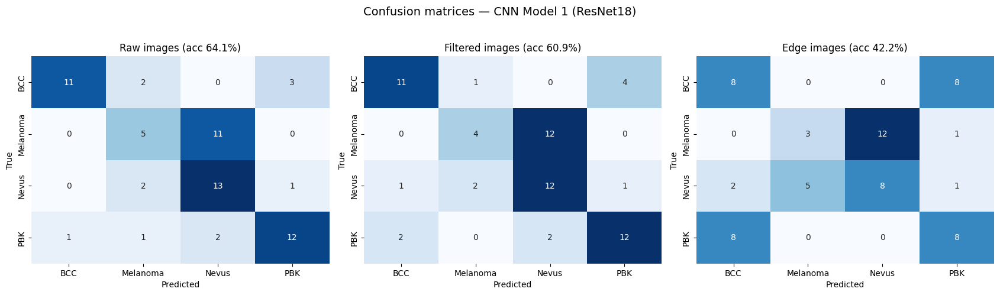

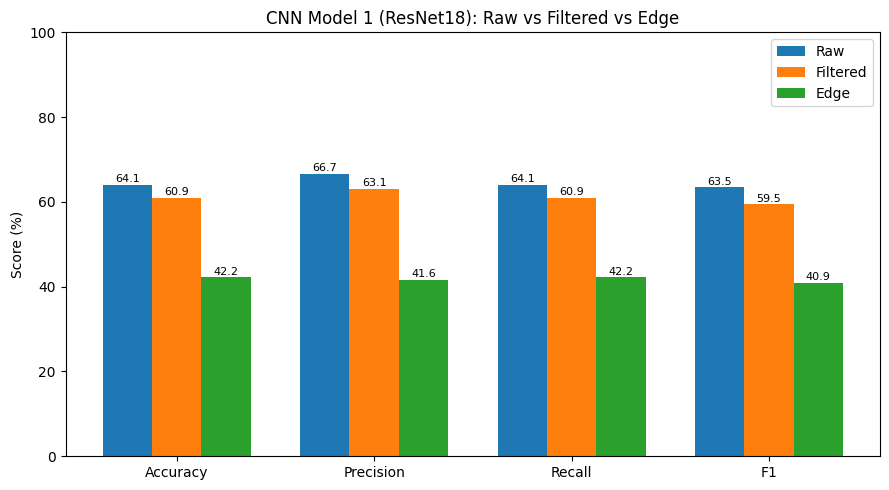

In [14]:
# ============ CELL 12: TASK 6 — CONFUSION MATRICES + BAR CHART ============
mean_acc = results_df.groupby("Model")[["Accuracy", "F1"]].mean()
best_model = mean_acc.sort_values(["Accuracy", "F1"], ascending=False).index[0]      # best average accuracy across the 3 representations
print("Best-performing model (highest mean accuracy over Raw/Filtered/Edge):", best_model)
print(mean_acc.round(4).loc[model_order], "\n")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
labels = [short_names[c] for c in class_names]
for ax, s in zip(axes, SET_NAMES):
    cm = confusion_matrix(y_test, PRED[(best_model, s)], labels=range(len(class_names)))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
    a = accuracy_score(y_test, PRED[(best_model, s)]) * 100
    ax.set_title(f"{s} images (acc {a:.1f}%)"); ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.suptitle(f"Confusion matrices — {best_model}", y=1.03, fontsize=14)
plt.tight_layout(); save_fig("task6_confusion_matrices.png"); plt.show()

sub = results_df[results_df["Model"] == best_model].set_index("Set").loc[SET_NAMES]
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x, w = np.arange(len(metrics)), 0.25
plt.figure(figsize=(9, 5))
for j, s in enumerate(SET_NAMES):
    vals = [sub.loc[s, m] * 100 for m in metrics]
    bars = plt.bar(x + (j - 1) * w, vals, w, label=s)
    for b, v in zip(bars, vals): plt.text(b.get_x() + b.get_width() / 2, v + 0.6, f"{v:.1f}", ha="center", fontsize=8)
plt.xticks(x, metrics); plt.ylabel("Score (%)"); plt.ylim(0, 100)
plt.title(f"{best_model}: Raw vs Filtered vs Edge"); plt.legend()
plt.tight_layout(); save_fig("task6_metric_bars.png"); plt.show()

In [15]:
# ============ CELL 13: SAVE EVERYTHING + FACTS FOR THE DISCUSSION QUESTIONS ============
print("=== Facts to quote in the report (Discussion Q1-Q7) ===")
g0 = grid[grid["Preprocessing"] == "None"].pivot_table(index="Detector", columns="Noise", values="F1")
g0["Mean"] = g0.mean(axis=1)
print("\nQ1 — F1 vs clean edges, no preprocessing (lower = more noise-sensitive):")
display(g0.sort_values("Mean").round(3))
print("Least robust detector:", g0["Mean"].idxmin(), "| Most robust:", g0["Mean"].idxmax())

print("\nQ2 — mean F1 gain from filtering (filter minus no filter):")
piv = grid.pivot_table(index=["Detector", "Noise"], columns="Preprocessing", values="F1")
print(pd.DataFrame({"Gaussian filter gain": piv["Gaussian Filter"] - piv["None"], "Median filter gain": piv["Median Filter"] - piv["None"]}).round(3))

print("\nQ3 — Canny thresholds (Table 2):")
display(table2[["Configuration", "Low Threshold", "High Threshold", "Kernel Size", "Number of Detected Edges", "Val accuracy (%)"]])

print("\nQ4/Q7 — accuracy by representation (%):")
q = acc.copy(); q["Edge - Raw"] = q["Edge"] - q["Raw"]; q["Filtered - Raw"] = q["Filtered"] - q["Raw"]
display(q.round(2))
print("Mean accuracy per representation:", acc.mean().round(2).to_dict())
print(f"Note: the test set has {len(y_test)} images, so one image = {100/len(y_test):.2f} percentage points. Treat differences of a few points as noise.")

shutil.make_archive("/content/lab03_outputs", "zip", OUT_DIR)
print("\nSaved to", OUT_DIR, "and /content/lab03_outputs.zip")
try:
    from google.colab import files; files.download("/content/lab03_outputs.zip")
except Exception: pass

=== Facts to quote in the report (Discussion Q1-Q7) ===

Q1 — F1 vs clean edges, no preprocessing (lower = more noise-sensitive):


Noise,Gaussian,Salt & Pepper,Mean
Detector,,,
Canny,0.165,0.096,0.130
Laplacian,0.353,0.479,0.416
Prewitt,0.450,0.561,0.505
Sobel,0.451,0.562,0.506
LoG,0.516,0.527,0.521


Least robust detector: Canny | Most robust: LoG

Q2 — mean F1 gain from filtering (filter minus no filter):
                         Gaussian filter gain  Median filter gain
Detector  Noise                                                  
Canny     Gaussian                      0.136               0.108
          Salt & Pepper                 0.171               0.134
Laplacian Gaussian                      0.014               0.148
          Salt & Pepper                -0.143               0.045
LoG       Gaussian                      0.055               0.072
          Salt & Pepper                 0.021               0.247
Prewitt   Gaussian                      0.185               0.176
          Salt & Pepper                -0.008               0.161
Sobel     Gaussian                      0.183               0.170
          Salt & Pepper                -0.011               0.153

Q3 — Canny thresholds (Table 2):


,Configuration,Low Threshold,High Threshold,Kernel Size,Number of Detected Edges,Val accuracy (%)
0,Canny-1,30,100,3×3,1925,43.73
1,Canny-2,50,150,3×3,729,40.67
2,Canny-3,100,200,3×3,271,36.09
3,Canny-4,50,150,5×5,412,40.06



Q4/Q7 — accuracy by representation (%):


Set,Edge,Filtered,Raw,Edge - Raw,Filtered - Raw
Model,,,,,
SVM,42.19,45.31,43.75,-1.56,1.56
Random Forest,37.50,46.88,43.75,-6.25,3.12
KNN,34.38,37.50,40.62,-6.25,-3.12
CNN Model 1 (ResNet18),42.19,60.94,64.06,-21.88,-3.12
CNN Model 2 (Small CNN),46.88,57.81,50.00,-3.12,7.81


Mean accuracy per representation: {'Edge': 40.62, 'Filtered': 49.69, 'Raw': 48.44}
Note: the test set has 64 images, so one image = 1.56 percentage points. Treat differences of a few points as noise.

Saved to /content/lab03_outputs and /content/lab03_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>